# Fundamentals 4 · Stochastic Gradient Descent on a Linear Neuron

A single linear neuron, $\hat{y} = w x + b$, is trained with stochastic gradient descent to predict a person's
weight from their height.

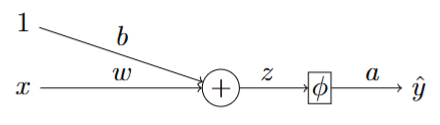

The first test uses just two hard-coded points, so the exact answer is known. (The column called "weight" is
the target $y$; the neuron's own parameters are $w$ and $b$.)

In [10]:
from pathlib import Path

# the repository root is the first folder above this notebook that holds pyproject.toml
REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
DATA_DIR = REPO_ROOT / "data"

import numpy as np

heights = [66, 72]
weights = [112, 136]

x = np.array(heights)
y = np.array(weights)

# The following 3 lines "standardize" the input. Doing this is important
# in helping gradient descent to converge. See
# https://www.quora.com/In-AI-how-would-1D-gradient-descent-look-like

x_mean = np.mean(x)
x_std = np.std(x)

print(f"Mean of heights (x): {x_mean}")
print(f"Standard Deviation of heights (x): {x_std}")

x = (x - np.mean(x)) / np.std(x)

print(x)
print(y)
print(type(x))

Mean of heights (x): 69.0
Standard Deviation of heights (x): 3.0
[-1.  1.]
[112 136]
<class 'numpy.ndarray'>


## The exact solution

After standardizing, the two $x$ values are −1 and +1, so the line through (−1, 112) and (1, 136) can be
solved by hand:

*$y = w*x + b$ is a linear equation*

*w is the slope so, $w = \frac{136-112}{1 - (-1)} = \frac{24}{2} = 12$*

$b$ is the intercept, so $b = y - w x = 112 - (-1)(12) = 124$

*Thus, w = 12; b = 124*

## Stochastic gradient descent

Stochastic gradient descent updates the parameters after every single data point instead of after the whole
dataset. For the squared error $(y - \hat{y})^2$ the updates are $w \leftarrow w + \eta \cdot 2(y - \hat{y})x$ and
$b \leftarrow b + \eta \cdot 2(y - \hat{y})$.

The `Perceptron` class keeps the forward pass, the loss and the update together — the same split into
forward, backward and step that `numpy_nn` uses later. Trained on the two points, it should recover
$w = 12$ and $b = 124$ with a loss close to 0.

In [11]:
import numpy as np
import random

class Perceptron:
    def __init__(
        self
    ):
        self.w = random.uniform(-1.0, 1.0)
        self.b = random.uniform(-1.0, 1.0)
        self.avg_loss = 0.0

    def forward(self, x):
        z = self.w*x + self.b
        return z

    def loss(self, y, ypred):
        # one data point
        diff = y - ypred
        return diff**2

    def train(self, inputs, targets, num_epochs, learning_rate):
        print_interval = 10
        for epoch in range(num_epochs):
            total_loss = 0.0
            for input, target in zip(inputs, targets):
                y_pred = self.forward(input)
                loss = self.loss(target, y_pred)
                total_loss += loss

                self.sgd(input, target, y_pred, learning_rate)

            self.avg_loss = total_loss/len(inputs)
            
            if epoch % print_interval == 0: 
                print(f"Epoch: {epoch}/{num_epochs} | Loss: {self.avg_loss} | Weight: {self.w}, Bias: {self.b}")

        print(f"Epoch: {num_epochs}/{num_epochs} | Loss: {self.avg_loss} | Weight: {self.w}, Bias: {self.b}")

        print("Training Completed")

    def sgd(self, x, y, ypred, learning_rate):
        change_w = 2 * (y - ypred) * x
        change_b = 2 * (y- ypred)

        self.w += learning_rate * change_w
        self.b += learning_rate * change_b

Training on the two points recovers $w = 12$, $b = 124$ with a loss of about $10^{-25}$:

In [12]:
perceptron = Perceptron()

perceptron.train(x, y, 1000, 0.01)

Epoch: 0/1000 | Loss: 15747.403481617695 | Weight: 0.9097322946121682, Bias: 4.042453297503205
Epoch: 10/1000 | Loss: 6960.390666156083 | Weight: 4.626828087575592, Bias: 44.24830801870545
Epoch: 20/1000 | Loss: 3076.5096151925018 | Weight: 7.098074681844383, Bias: 70.97847239529368
Epoch: 30/1000 | Loss: 1359.8247377684847 | Weight: 8.741040069297124, Bias: 88.74955803826697
Epoch: 40/1000 | Loss: 601.0458437430974 | Weight: 9.833337078680128, Bias: 100.56435575071562
Epoch: 50/1000 | Loss: 265.66372580755205 | Weight: 10.559531778713867, Bias: 108.41921885758917
Epoch: 60/1000 | Loss: 117.42401340041002 | Weight: 11.04232971538035, Bias: 113.64138820228432
Epoch: 70/1000 | Loss: 51.90169971886945 | Weight: 11.363309540265584, Bias: 117.11325681331202
Epoch: 80/1000 | Loss: 22.9406775982187 | Weight: 11.576707403344127, Bias: 119.42146837379771
Epoch: 90/1000 | Loss: 10.13983533325561 | Weight: 11.718581267169588, Bias: 120.95604274998146
Epoch: 100/1000 | Loss: 4.481831896435285 | We

## A real, noisy dataset

The same neuron on `data/height_weight_10.csv`, and then on the full `data/height_weight.csv`. The data is
noisy, so the loss no longer reaches 0: it settles at the spread the best line cannot explain (about 72 on
the small file and 104 on the full one — square error, in pounds²).

,height,weight
0,67.0,128.0
1,67.0,123.0
2,72.0,129.0
3,69.0,143.0
4,69.0,132.0


Epoch: 0/1000 | Loss: 13770.210390937278 | Weight: 1.7177860334118062, Bias: 22.423304777927502
Epoch: 10/1000 | Loss: 301.27891805804194 | Weight: 7.3807137171186525, Bias: 111.9226607893862
Epoch: 20/1000 | Loss: 76.10829218397198 | Weight: 7.671757315622387, Bias: 123.53391702117372
Epoch: 30/1000 | Loss: 72.32758020829766 | Weight: 7.654226528319828, Bias: 125.0404770065636
Epoch: 40/1000 | Loss: 72.25749238760409 | Weight: 7.64506082394003, Bias: 125.23597381633324
Epoch: 50/1000 | Loss: 72.25463511756286 | Weight: 7.643012662904295, Bias: 125.26134478916019
Epoch: 60/1000 | Loss: 72.25426418469537 | Weight: 7.642639846142967, Bias: 125.26463767747128
Epoch: 70/1000 | Loss: 72.25420289907558 | Weight: 7.642578124966472, Bias: 125.2650651002013
Epoch: 80/1000 | Loss: 72.2541930845754 | Weight: 7.642568452307612, Bias: 125.26512058542225
Epoch: 90/1000 | Loss: 72.2541915751074 | Weight: 7.642566989733227, Bias: 125.26512778877256
Epoch: 100/1000 | Loss: 72.25419134975363 | Weight: 7

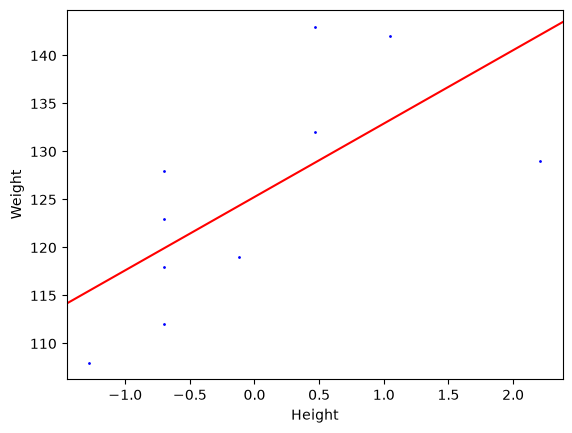

In [13]:
import pandas as pd

df = pd.read_csv(DATA_DIR / "height_weight_10.csv")
display(df.head())
x = df.height.to_numpy()
y = df.weight.to_numpy()

# normalize data
x_mean = np.mean(x)
x_std = np.std(x)
x = (x - np.mean(x)) / np.std(x)

perceptron_csv = Perceptron()
perceptron_csv.train(x, y, 1000, 0.01)

# If you want to see the dataset, especially helpful on the full dataset:
import matplotlib.pyplot as plt
plt.scatter(x, y, s=1, color="blue")

m = perceptron_csv.w
b = perceptron_csv.b
plt.axline((0, b), slope=m, color='red', label=f'y = {m}x + {b}')

plt.xlabel("Height")
plt.ylabel("Weight")
plt.show()

,height,weight
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971


Epoch: 0/100 | Loss: 120.2313160975878 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 10/100 | Loss: 103.60012000006864 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 20/100 | Loss: 103.60012000006864 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 30/100 | Loss: 103.60012000006864 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 40/100 | Loss: 103.60012000006864 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 50/100 | Loss: 103.60012000006864 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 60/100 | Loss: 103.60012000006864 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 70/100 | Loss: 103.60012000006864 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 80/100 | Loss: 103.60012000006864 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 90/100 | Loss: 103.60012000006864 | Weight: 5.842875211365817, Bias: 126.16067364786383
Epoch: 100/100 | Loss: 103.60012000006864 | Weight: 

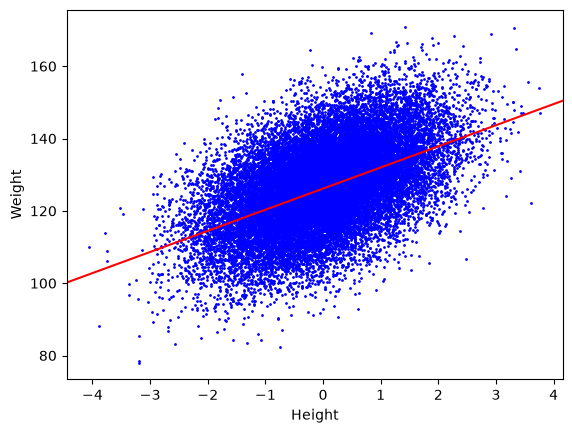

In [14]:
import pandas as pd

df = pd.read_csv(DATA_DIR / "height_weight.csv")
display(df.head())
x = df.height.to_numpy()
y = df.weight.to_numpy()

# normalize data
x_mean = np.mean(x)
x_std = np.std(x)
x = (x - np.mean(x)) / np.std(x)

perceptron_csv = Perceptron()
perceptron_csv.train(x, y, 100, 0.01)

# If you want to see the dataset, especially helpful on the full dataset:
import matplotlib.pyplot as plt
plt.scatter(x, y, s=1, color="blue")
plt.xlabel("Height")
plt.ylabel("Weight")

m = perceptron_csv.w
b = perceptron_csv.b
plt.axline((0, b), slope=m, color='red', label=f'y = {m}x + {b}')

plt.show()